# Sinhala Buddhist Corpus - Language Detection & Separation

This notebook uses **language detection models** to separate:
- **Sinhala language** - Modern Sinhala text
- **Pali transliterations** - Pali written in Sinhala script

**Strategy:**
1. Use fastText language detection
2. If confidently detected as Sinhala → Sinhala corpus
3. If not confidently Sinhala (or detected as other) → Pali corpus
4. Manual review for ambiguous cases

## 1. Setup and Installation

In [1]:
# Install required packages
!pip install fasttext langdetect lingua-language-detector -q
print("✓ Packages installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 22.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.2/96.2 MB 8.3 MB/s eta 0:00:00
✓ Packages installed


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
import re
import json
from pathlib import Path
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Language detection libraries
import fasttext
from langdetect import detect, DetectorFactory, detect_langs
from lingua import Language, LanguageDetectorBuilder

# Set seed for reproducibility
DetectorFactory.seed = 0

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported")

✓ Libraries imported


In [5]:
# Directory configuration
BASE_DIR = Path("/content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/")

# Input directories (cleaned text from previous processing)
EXTRACTION_BASE = BASE_DIR / "data" / "docai_extractions"
CLEANED_TEXT_DIR = EXTRACTION_BASE / "2_cleaned_text"

# Output directories
PREPROCESSED_DIR = BASE_DIR / "data" / "preprocessed"
ANALYSIS_DIR = PREPROCESSED_DIR / "analysis"
SINHALA_CORPUS_FILE = PREPROCESSED_DIR / "sinhala_text_corpus.txt"
PALI_CORPUS_FILE = PREPROCESSED_DIR / "pali_text_corpus.txt"
MIXED_CORPUS_FILE = PREPROCESSED_DIR / "mixed_text_corpus.txt"  # For uncertain cases

# Create directories
PREPROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

print("✓ Directory structure created")
print(f"  Input: {CLEANED_TEXT_DIR}")
print(f"  Output: {PREPROCESSED_DIR}")

✓ Directory structure created
  Input: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/docai_extractions/2_cleaned_text
  Output: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed


## 2. Download fastText Language Detection Model

In [6]:
# Download fastText pretrained language identification model
!wget -q https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin

# Load the model
fasttext_model = fasttext.load_model('lid.176.bin')
print("✓ fastText model loaded")
print(f"  Model supports {len(fasttext_model.labels)} languages")

✓ fastText model loaded
  Model supports 176 languages


## 3. Language Detection Functions

In [7]:
def detect_language_fasttext(text: str, model) -> Tuple[str, float]:
    """
    Detect language using fastText.

    Returns:
        Tuple of (language_code, confidence)
        Example: ('si', 0.95) for Sinhala with 95% confidence
    """
    if not text or len(text.strip()) < 10:
        return 'unknown', 0.0

    # Clean text (remove newlines for better detection)
    text_clean = ' '.join(text.split())

    try:
        predictions = model.predict(text_clean, k=1)
        language = predictions[0][0].replace('__label__', '')
        confidence = float(predictions[1][0])
        return language, confidence
    except:
        return 'unknown', 0.0


def detect_language_langdetect(text: str) -> Tuple[str, float]:
    """
    Detect language using langdetect (backup method).

    Returns:
        Tuple of (language_code, confidence)
    """
    if not text or len(text.strip()) < 10:
        return 'unknown', 0.0

    try:
        langs = detect_langs(text)
        if langs:
            return langs[0].lang, langs[0].prob
        return 'unknown', 0.0
    except:
        return 'unknown', 0.0


def is_sinhala_char(char: str) -> bool:
    """Check if character is Sinhala Unicode."""
    code = ord(char)
    return 0x0D80 <= code <= 0x0DFF


def calculate_sinhala_script_ratio(text: str) -> float:
    """
    Calculate ratio of Sinhala script characters.
    Both Sinhala and Pali use Sinhala script, so this should be high for both.
    """
    if not text:
        return 0.0

    sinhala_count = sum(1 for c in text if is_sinhala_char(c))
    alpha_count = sum(1 for c in text if c.isalpha())

    return sinhala_count / alpha_count if alpha_count > 0 else 0.0


def has_pali_markers(text: str) -> bool:
    """
    Check for Pali-specific grammatical markers.

    Common Pali endings and particles:
    - Genitive: -ස්ස, -තෝ, -ානං
    - Verbs: -ති, -න්ති, -තේ
    - Compounds: Long compound words without Sinhala particles
    """
    pali_patterns = [
        r'ස්ස\s',  # Genitive ending
        r'තෝ\s',   # Genitive ending
        r'ති\s',   # Verb ending
        r'න්ති',   # Verb ending
        r'තේ\s',   # Verb ending
        r'ානං',    # Plural genitive
        r'භගවතෝ', # "Blessed One" (Pali)
        r'තථාගතස්ස', # "Tathagata" (Pali genitive)
    ]

    for pattern in pali_patterns:
        if re.search(pattern, text):
            return True

    return False


def has_sinhala_markers(text: str) -> bool:
    """
    Check for Sinhala-specific grammatical markers.

    Common Sinhala particles and endings:
    - Particles: ද, නේ, යි, වා
    - Verb: වූ, වන, ගත්, කළ
    - Case markers: ට, හි, ගේ, යේ, ෙයන්
    """
    sinhala_patterns = [
        r'\sවූ\s',   # "was/were"
        r'\sවන\s',   # "is/are"
        r'හි\s',     # Locative case
        r'ට\s',      # Dative case
        r'ගේ\s',     # Possessive
        r'යි\s',     # Emphatic particle
        r'\sද\s',    # Question particle
        r'නේ\s',     # Question particle
        r'යේ\s',     # Locative
        r'කළ\s',     # "did"
        r'ගත්\s',    # "took"
    ]

    for pattern in sinhala_patterns:
        if re.search(pattern, text):
            return True

    return False


print("✓ Language detection functions defined")

✓ Language detection functions defined


In [32]:
# Robust Sinhala vs Pali Classifier
# Based on real corpus analysis

import re
from typing import Tuple, Dict

class SinhalaPaliClassifier:
    """
    Classify text as Sinhala or Pali transliteration.

    Strategy:
    1. Strong pattern matching (Pali grammatical endings vs Sinhala particles)
    2. Word-level vocabulary analysis
    3. Confidence scoring
    """

    def __init__(self):
        # Pali grammatical endings (genitive, dative, ablative, etc.)
        self.pali_endings = [
            r'තෝ\b',      # Genitive: භගවතෝ
            r'ස්ස\b',     # Genitive: තථාගතස්ස
            r'නො\b',      # Nominative plural: සබ්බඤ්ඤුනො
            r'ාය\b',      # Dative: බුද්ධාය
            r'ානං\b',     # Genitive plural
            r'ස්මා\b',    # Ablative
            r'ස්මිං\b',   # Locative
            r'ති\b',      # Verb 3rd person: ගච්ඡති
            r'න්ති\b',    # Verb 3rd plural: ගච්ඡන්ති
            r'තේ\b',      # Verb middle: ලභතේ
            r'න්තේ\b',    # Verb middle plural
            r'ම්හි\b',    # 1st person plural
            r'න්‍යං\b',   # Accusative
        ]

        # Sinhala grammatical particles and case markers
        self.sinhala_particles = [
            r'\bවූ\b',     # Past participle "was/were"
            r'\bවන\b',     # Present participle "is/are"
            r'\bකළ\b',     # Past "did"
            r'\bගත්\b',    # Past "took"
            r'\bදුන්\b',   # Past "gave"
            r'හි\b',       # Locative case "in/at"
            r'ට\b',        # Dative case "to"
            r'ගේ\b',       # Genitive "of/belonging to"
            r'යේ\b',       # Locative "at"
            r'ෙයන්\b',    # Instrumental "by"
            r'යි\b',       # Emphatic particle
            r'\bද\b',      # Question particle
            r'නේ\b',       # Question particle
            r'වා\b',       # Conjunctive "and"
            r'මු\b',       # 1st person past
            r'මි\b',       # 1st person present
            r'හ\b',        # Plural marker
        ]

        # Known Pali words (common in Buddhist texts)
        self.pali_words = [
            'භගවතෝ', 'තථාගතස්ස', 'සබ්බඤ්ඤුනො', 'සම්මාසම්බුද්ධස්ස',
            'ධම්මස්ස', 'සඞ්ඝස්ස', 'භික්ඛුනො', 'භික්ඛූනං',
            'සුඛස්ස', 'දුක්ඛස්ස', 'නමො', 'භන්තේ',
            'අවිජ්ජා', 'සඞ්ඛාරා', 'විඤ්ඤාණං', 'නාමරූපං',
            'සදිසො', 'යස්මා', 'යත්ථ', 'යතො', 'තස්මා', 'තත්‍ර'
        ]

        # Known Sinhala words (modern usage)
        self.sinhala_words = [
            'මාගේ', 'අපගේ', 'ඔබගේ', 'එසේ', 'මෙසේ', 'ඒ', 'මේ',
            'කියන', 'කියා', 'කියමු', 'කරන', 'කරමු', 'බව', 'යන',
            'නිසා', 'හෙයින්', 'සිට', 'දක්වා', 'පටන්', 'තෙක්',
            'පිළිබඳ', 'අනුව', 'විසින්', 'කෙරෙහි', 'තුළ', 'මගින්'
        ]

        # Compile regex patterns for efficiency
        self.pali_ending_pattern = re.compile('|'.join(self.pali_endings))
        self.sinhala_particle_pattern = re.compile('|'.join(self.sinhala_particles))

    def count_pali_features(self, text: str) -> int:
        """Count Pali grammatical features."""
        count = 0

        # Count Pali endings
        count += len(self.pali_ending_pattern.findall(text))

        # Count Pali words
        for word in self.pali_words:
            count += text.count(word)

        return count

    def count_sinhala_features(self, text: str) -> int:
        """Count Sinhala grammatical features."""
        count = 0

        # Count Sinhala particles
        count += len(self.sinhala_particle_pattern.findall(text))

        # Count Sinhala words
        for word in self.sinhala_words:
            count += text.count(word)

        return count

    def classify(self, text: str, threshold: float = 0.6) -> Tuple[str, Dict]:
        """
        Classify text as 'sinhala' or 'pali'.

        Args:
            text: Text to classify
            threshold: Confidence threshold (0.0 to 1.0)

        Returns:
            Tuple of (language, debug_info)
        """
        if not text or len(text.strip()) < 50:
            return 'unknown', {'reason': 'Text too short'}

        # Count features
        pali_features = self.count_pali_features(text)
        sinhala_features = self.count_sinhala_features(text)
        total_features = pali_features + sinhala_features

        debug_info = {
            'text_length': len(text),
            'pali_features': pali_features,
            'sinhala_features': sinhala_features,
            'total_features': total_features
        }

        # If no features detected, try heuristics
        if total_features == 0:
            # Check for very long compound words (common in Pali)
            words = text.split()
            long_words = [w for w in words if len(w) > 25]

            if len(long_words) > 2:
                debug_info['reason'] = 'Long compound words (Pali characteristic)'
                debug_info['confidence'] = 0.6
                return 'pali', debug_info

            # Default to mixed/uncertain
            debug_info['reason'] = 'No distinctive features found'
            debug_info['confidence'] = 0.0
            return 'mixed', debug_info

        # Calculate confidence
        pali_ratio = pali_features / total_features
        sinhala_ratio = sinhala_features / total_features

        debug_info['pali_ratio'] = pali_ratio
        debug_info['sinhala_ratio'] = sinhala_ratio

        # Decision logic
        if sinhala_ratio >= threshold:
            debug_info['confidence'] = sinhala_ratio
            debug_info['reason'] = f'Strong Sinhala features ({sinhala_ratio:.2%})'
            return 'sinhala', debug_info
        elif pali_ratio >= threshold:
            debug_info['confidence'] = pali_ratio
            debug_info['reason'] = f'Strong Pali features ({pali_ratio:.2%})'
            return 'pali', debug_info
        else:
            # Mixed or uncertain - use majority
            if sinhala_features > pali_features:
                debug_info['confidence'] = sinhala_ratio
                debug_info['reason'] = f'Moderate Sinhala features ({sinhala_ratio:.2%})'
                return 'sinhala', debug_info
            else:
                debug_info['confidence'] = pali_ratio
                debug_info['reason'] = f'Moderate Pali features ({pali_ratio:.2%})'
                return 'pali', debug_info



sinhala_pali_classifier = SinhalaPaliClassifier()

## 4. Hybrid Classification Function

In [29]:
def classify_text_language_hybrid(
    text: str,
    fasttext_model,
    sinhala_confidence_threshold: float = 0.6,
    min_sinhala_script_ratio: float = 0.80,
    sinhala_classifier: Optional['SinhalaPaliClassifier'] = None
) -> Tuple[str, Dict]:
    """
    Classify text as 'sinhala' or 'pali' using hybrid approach.

    Strategy:
    1. Check if text is in Sinhala script (both Sinhala and Pali will pass)
    2. Use fastText to detect if it's Sinhala language
    3. Use SinhalaPaliClassifier for fine-grained Sinhala vs Pali distinction
    4. If confidently Sinhala by any method → 'sinhala'
    5. Otherwise → 'pali'

    Args:
        text: Text to classify
        fasttext_model: Loaded fastText model
        sinhala_confidence_threshold: Minimum confidence for Sinhala (0.0-1.0)
        min_sinhala_script_ratio: Minimum ratio of Sinhala script (0.0-1.0)
        sinhala_classifier: An instance of SinhalaPaliClassifier. If None, the global 'classifier' will be used.

    Returns:
        Tuple of (language, debug_info)
    """
    debug_info = {
        'text_length': len(text),
        'text_preview': text[:100],
        'sinhala_script_ratio': 0.0,
        'fasttext_lang': 'unknown',
        'fasttext_confidence': 0.0,
        'langdetect_lang': 'unknown',
        'langdetect_confidence': 0.0,
        'classification': 'unknown'
    }

    # Ensure the classifier instance is available
    if sinhala_classifier is None:
        # Access the global 'classifier' instance. This assumes it's defined elsewhere.
        if 'classifier' in globals():
            sinhala_classifier = globals()['classifier']
        else:
            # Fallback for when global classifier is not defined (e.g., cell not run)
            # This scenario should ideally not happen if cells are run in order
            debug_info['classification'] = 'error'
            debug_info['reason'] = 'SinhalaPaliClassifier instance not found.'
            return 'error', debug_info

    # Check 1: Must be in Sinhala script
    sinhala_script_ratio = calculate_sinhala_script_ratio(text)
    debug_info['sinhala_script_ratio'] = sinhala_script_ratio

    if sinhala_script_ratio < min_sinhala_script_ratio:
        # Not enough Sinhala script - probably corrupted or very short
        debug_info['classification'] = 'mixed'
        debug_info['reason'] = 'Not enough Sinhala script characters'
        return 'mixed', debug_info

    # Check 2: fastText language detection
    ft_lang, ft_conf = detect_language_fasttext(text, fasttext_model)
    debug_info['fasttext_lang'] = ft_lang
    debug_info['fasttext_confidence'] = ft_conf

    # Check 3: langdetect as backup
    ld_lang, ld_conf = detect_language_langdetect(text)
    debug_info['langdetect_lang'] = ld_lang
    debug_info['langdetect_confidence'] = ld_conf

    # Decision logic

    # Strong Sinhala indicators from general language models
    if ft_lang == 'si' and ft_conf >= sinhala_confidence_threshold:
        debug_info['classification'] = 'sinhala'
        debug_info['reason'] = f'fastText confident Sinhala ({ft_conf:.2f})'
        return 'sinhala', debug_info

    # Backup: langdetect says Sinhala with high confidence
    if ld_lang == 'si' and ld_conf >= 0.9:
        debug_info['classification'] = 'sinhala'
        debug_info['reason'] = f'langdetect confident Sinhala ({ld_conf:.2f})'
        return 'sinhala', debug_info

    # If not confidently Sinhala by general models, use the specialized SinhalaPaliClassifier
    classifier_result, classifier_debug = sinhala_classifier.classify(text)
    debug_info['sinhala_pali_classifier_details'] = classifier_debug # Add classifier's debug info

    if classifier_result == 'sinhala':
        debug_info['classification'] = 'sinhala'
        debug_info['reason'] = f"SinhalaPaliClassifier: {classifier_debug.get('reason', 'N/A')}"
        return 'sinhala', debug_info
    elif classifier_result == 'pali':
        debug_info['classification'] = 'pali'
        debug_info['reason'] = f"SinhalaPaliClassifier: {classifier_debug.get('reason', 'N/A')}"
        return 'pali', debug_info
    else: # 'mixed' or 'unknown' from SinhalaPaliClassifier
        # If all methods are uncertain or point away from Sinhala, default to Pali
        debug_info['classification'] = 'pali'
        debug_info['reason'] = 'No confident Sinhala detection from any method, defaulting to Pali.'
        return 'pali', debug_info


print("\u2713 Hybrid classification function defined")

✓ Hybrid classification function defined


## 5. Load Corpus

In [9]:
def load_all_text_files(text_dir: Path) -> Dict[str, List[str]]:
    """
    Load all text files organized by PDF.
    """
    corpus = {}

    pdf_dirs = [d for d in text_dir.iterdir() if d.is_dir()]

    for pdf_dir in tqdm(pdf_dirs, desc="Loading text files"):
        pdf_name = pdf_dir.name
        page_texts = []

        txt_files = [f for f in pdf_dir.glob("*.txt")]

        def get_page_number(file_path):
            try:
                stem = file_path.stem
                if '_' in stem:
                    return int(stem.split('_')[-1])
                else:
                    return int(stem)
            except:
                return 0

        txt_files_sorted = sorted(txt_files, key=get_page_number)

        for page_file in txt_files_sorted:
            try:
                with open(page_file, 'r', encoding='utf-8') as f:
                    text = f.read().strip()
                    if text and len(text) > 50:  # Only include substantial pages
                        page_texts.append(text)
            except Exception as e:
                print(f"  Warning: Error reading {page_file}: {e}")

        if page_texts:
            corpus[pdf_name] = page_texts

    return corpus


print("Loading corpus...")
corpus = load_all_text_files(CLEANED_TEXT_DIR)
print(f"✓ Loaded {len(corpus)} PDFs")
print(f"  Total pages: {sum(len(pages) for pages in corpus.values())}")

Loading corpus...


Loading text files:   0%|          | 0/34 [00:00<?, ?it/s]

✓ Loaded 34 PDFs
  Total pages: 10511


## 6. Test on Sample Texts

Let's test the classifier on a few pages to see how it performs.

In [34]:
# Get first few pages from first PDF for testing
test_pdf = list(corpus.keys())[0]
test_pages = corpus[test_pdf][:5]  # First 5 pages

print(f"Testing on first 5 pages from: {test_pdf}\n")
print("="*80)

for i, page_text in enumerate(test_pages, 1):
    lang, debug_info = classify_text_language_hybrid(
        page_text,
        fasttext_model,
        sinhala_confidence_threshold=0.1,
        sinhala_classifier = sinhala_pali_classifier
    )

    print(f"\nPage {i}:")
    print(f"  Classification: {lang.upper()}")
    print(f"  Reason: {debug_info.get('reason', 'N/A')}")
    print(f"  fastText: {debug_info['fasttext_lang']} ({debug_info['fasttext_confidence']:.3f})")
    print(f"  langdetect: {debug_info['langdetect_lang']} ({debug_info['langdetect_confidence']:.3f})")
    if 'sinhala_pali_classifier_details' in debug_info:
        classifier_details = debug_info['sinhala_pali_classifier_details']
        print(f"  Pali features: {classifier_details.get('pali_features', 'N/A')}")
        print(f"  Sinhala features: {classifier_details.get('sinhala_features', 'N/A')}")
        print(f"  Pali ratio (classifier): {classifier_details.get('pali_ratio', 'N/A'):.3f}")
        print(f"  Sinhala ratio (classifier): {classifier_details.get('sinhala_ratio', 'N/A'):.3f}")
    print(f"  Text preview: {page_text[:150]}...")
    print("-"*80)

Testing on first 5 pages from: අංගුත්තර_නිකාය_1


Page 1:
  Classification: SINHALA
  Reason: SinhalaPaliClassifier: Strong Sinhala features (80.80%)
  fastText: unknown (0.000)
  langdetect: unknown (0.000)
  Pali features: 24
  Sinhala features: 101
  Pali ratio (classifier): 0.192
  Sinhala ratio (classifier): 0.808
  Text preview: නමෝ තස්ස භගවතෝ සබ්බධම්මේසු අප්පටිහතඤාණචාරස්ස දසබලධරස්ස
චතුවේසාරජ්ජවිසාරදස්ස සබ්බසත්තුත්තමස්ස ධම්මිස්සරස්ස ධම්මරාජස්ස ධම්මස්සාමිස්ස
තථාගතස්ස සබ්බඤ්ඤුනො...
--------------------------------------------------------------------------------

Page 2:
  Classification: SINHALA
  Reason: SinhalaPaliClassifier: Strong Sinhala features (91.22%)
  fastText: unknown (0.000)
  langdetect: unknown (0.000)
  Pali features: 13
  Sinhala features: 135
  Pali ratio (classifier): 0.088
  Sinhala ratio (classifier): 0.912
  Text preview: සංඥාපනය

අංගුත්තර නිකාය :

අප බුදුන් බරණැස්නුවර ඍෂීන් මුළු දෙන මුවළැවහි දී " ධර්ම චක්‍ර'ය
පැවැත් වූ තැන් පටන් කොට සුභද්‍ර පරිව්‍රාජක දමනය තෙ

## 7. Classify Entire Corpus

In [35]:
def classify_corpus(
    corpus: Dict[str, List[str]],
    fasttext_model,
    sinhala_confidence_threshold: float = 0.7,
    sinhala_classifier: Optional['SinhalaPaliClassifier'] = None
) -> Tuple[List[str], List[str], List[str], Dict]:
    """
    Classify entire corpus into Sinhala, Pali, and Mixed.

    Returns:
        Tuple of (sinhala_texts, pali_texts, mixed_texts, statistics)
    """
    sinhala_texts = []
    pali_texts = []
    mixed_texts = []

    stats = {
        'total_pages': 0,
        'sinhala_pages': 0,
        'pali_pages': 0,
        'mixed_pages': 0,
        'pdf_classifications': defaultdict(lambda: {'sinhala': 0, 'pali': 0, 'mixed': 0}),
        'classification_reasons': defaultdict(int),
        'detailed_logs': []
    }

    print("\nClassifying pages...")

    for pdf_name, page_texts in tqdm(corpus.items(), desc="Processing PDFs"):
        for page_num, page_text in enumerate(page_texts, 1):
            stats['total_pages'] += 1

            # Classify this page
            language, debug_info = classify_text_language_hybrid(
                page_text,
                fasttext_model,
                sinhala_confidence_threshold=sinhala_confidence_threshold,
                sinhala_classifier = sinhala_classifier
            )

            # Track reason
            reason = debug_info.get('reason', 'unknown')
            stats['classification_reasons'][reason] += 1

            # Store detailed log (for first 100 pages only, to save memory)
            if len(stats['detailed_logs']) < 100:
                stats['detailed_logs'].append({
                    'pdf': pdf_name,
                    'page': page_num,
                    'language': language,
                    'debug': debug_info
                })

            # Categorize
            if language == 'sinhala':
                sinhala_texts.append(page_text)
                stats['sinhala_pages'] += 1
                stats['pdf_classifications'][pdf_name]['sinhala'] += 1
            elif language == 'pali':
                pali_texts.append(page_text)
                stats['pali_pages'] += 1
                stats['pdf_classifications'][pdf_name]['pali'] += 1
            else:  # mixed
                mixed_texts.append(page_text)
                stats['mixed_pages'] += 1
                stats['pdf_classifications'][pdf_name]['mixed'] += 1

    print(f"\n✓ Classification complete")
    print(f"   Total pages: {stats['total_pages']}")
    print(f"   Sinhala: {stats['sinhala_pages']} ({stats['sinhala_pages']/stats['total_pages']*100:.1f}%)")
    print(f"   Pali: {stats['pali_pages']} ({stats['pali_pages']/stats['total_pages']*100:.1f}%)")
    print(f"   Mixed: {stats['mixed_pages']} ({stats['mixed_pages']/stats['total_pages']*100:.1f}%)")

    return sinhala_texts, pali_texts, mixed_texts, dict(stats)


# Run classification with adjustable threshold
SINHALA_CONFIDENCE_THRESHOLD = 0.6  # Adjust this (0.0 to 1.0)
# Lower = more classified as Sinhala
# Higher = more classified as Pali

sinhala_texts, pali_texts, mixed_texts, classification_stats = classify_corpus(
    corpus,
    fasttext_model,
    sinhala_confidence_threshold=SINHALA_CONFIDENCE_THRESHOLD,
    sinhala_classifier = sinhala_pali_classifier
)


Classifying pages...


Processing PDFs:   0%|          | 0/34 [00:00<?, ?it/s]


✓ Classification complete
   Total pages: 10511
   Sinhala: 10220 (97.2%)
   Pali: 291 (2.8%)
   Mixed: 0 (0.0%)


## 8. Analyze Classification Results

In [36]:
# Print classification reasons breakdown
print("\n" + "="*80)
print("CLASSIFICATION REASONS BREAKDOWN")
print("="*80)

reasons_df = pd.DataFrame([
    {'Reason': reason, 'Count': count, 'Percentage': f"{count/classification_stats['total_pages']*100:.1f}%"}
    for reason, count in classification_stats['classification_reasons'].items()
]).sort_values('Count', ascending=False)

print(reasons_df.to_string(index=False))


CLASSIFICATION REASONS BREAKDOWN
                                                   Reason  Count Percentage
 SinhalaPaliClassifier: Strong Sinhala features (100.00%)     86       0.8%
  SinhalaPaliClassifier: Strong Sinhala features (66.67%)     82       0.8%
  SinhalaPaliClassifier: Strong Sinhala features (75.00%)     73       0.7%
  SinhalaPaliClassifier: Strong Sinhala features (71.43%)     55       0.5%
  SinhalaPaliClassifier: Strong Sinhala features (80.00%)     48       0.5%
  SinhalaPaliClassifier: Strong Sinhala features (93.33%)     40       0.4%
   SinhalaPaliClassifier: Moderate Pali features (50.00%)     40       0.4%
  SinhalaPaliClassifier: Strong Sinhala features (92.31%)     39       0.4%
  SinhalaPaliClassifier: Strong Sinhala features (93.75%)     38       0.4%
  SinhalaPaliClassifier: Strong Sinhala features (72.73%)     37       0.4%
  SinhalaPaliClassifier: Strong Sinhala features (85.71%)     35       0.3%
  SinhalaPaliClassifier: Strong Sinhala features (77.7

In [37]:
# Show PDFs with mixed content
print("\n" + "="*80)
print("PDFs WITH LANGUAGE DISTRIBUTION")
print("="*80)

pdf_dist_data = []
for pdf_name, counts in classification_stats['pdf_classifications'].items():
    total = counts['sinhala'] + counts['pali'] + counts['mixed']
    pdf_dist_data.append({
        'PDF': pdf_name[:40],  # Truncate long names
        'Sinhala': counts['sinhala'],
        'Pali': counts['pali'],
        'Mixed': counts['mixed'],
        'Total': total,
        'Primary': 'Sinhala' if counts['sinhala'] > counts['pali'] else 'Pali'
    })

pdf_dist_df = pd.DataFrame(pdf_dist_data).sort_values('Pali', ascending=False)
print(pdf_dist_df.head(15).to_string(index=False))
print(f"\n... and {len(pdf_dist_df) - 15} more PDFs")


PDFs WITH LANGUAGE DISTRIBUTION
                   PDF  Sinhala  Pali  Mixed  Total Primary
      මජ්ක්ධිම_නිකාය_1      397    29      0    426 Sinhala
            බන්ධක_වග්ග      211    25      0    236 Sinhala
           සළායතන_වග්ග      332    21      0    353 Sinhala
      අංගුත්තර_නිකාය_2      288    20      0    308 Sinhala
      අංගුත්තර_නිකාය_5      278    20      0    298 Sinhala
            නිදාන_වග්ග      200    19      0    219 Sinhala
      අංගුත්තර_නිකාය_3      237    16      0    253 Sinhala
      මජ්ක්ධිම_නිකාය_3      204    15      0    219 Sinhala
           දීඝ_නිකාය_3      316    14      0    330 Sinhala
      අංගුත්තර_නිකාය_6      409    13      0    422 Sinhala
      අංගුත්තර_නිකාය_1      355    12      0    367 Sinhala
පටිසම්භිදාමග්ගප්පකරණ_1      348    12      0    360 Sinhala
           දීඝ_නිකාය_2      275    12      0    287 Sinhala
      අංගුත්තර_නිකාය_4      319    11      0    330 Sinhala
        ග්‍රන්ථ_අංක_01      103    11      0    114 Sinhala

... an


✓ Visualization saved to: /content/drive/Othercomputers/My Mac/Multi-lingual-Buddhist-Conversational-Agent/data/preprocessed/analysis/language_classification_results.png


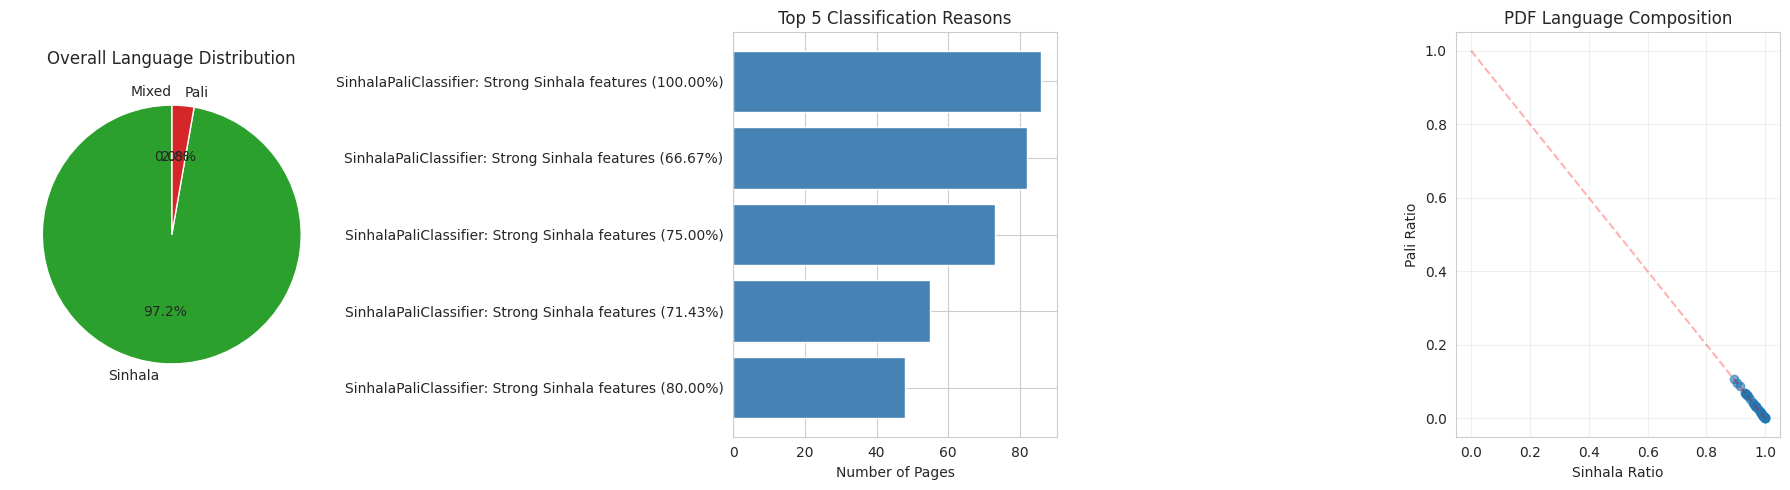

In [38]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie chart of overall distribution
labels = ['Sinhala', 'Pali', 'Mixed']
sizes = [
    classification_stats['sinhala_pages'],
    classification_stats['pali_pages'],
    classification_stats['mixed_pages']
]
colors = ['#2ca02c', '#d62728', '#ff7f0e']
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0].set_title('Overall Language Distribution')

# Bar chart of classification reasons
reasons_sorted = dict(sorted(
    classification_stats['classification_reasons'].items(),
    key=lambda x: x[1],
    reverse=True
)[:5])  # Top 5 reasons
axes[1].barh(list(reasons_sorted.keys()), list(reasons_sorted.values()), color='steelblue')
axes[1].set_xlabel('Number of Pages')
axes[1].set_title('Top 5 Classification Reasons')
axes[1].invert_yaxis()

# Scatter plot: PDFs by Sinhala vs Pali ratio
sinhala_ratios = []
pali_ratios = []
for counts in classification_stats['pdf_classifications'].values():
    total = counts['sinhala'] + counts['pali'] + counts['mixed']
    if total > 0:
        sinhala_ratios.append(counts['sinhala'] / total)
        pali_ratios.append(counts['pali'] / total)

axes[2].scatter(sinhala_ratios, pali_ratios, alpha=0.6)
axes[2].set_xlabel('Sinhala Ratio')
axes[2].set_ylabel('Pali Ratio')
axes[2].set_title('PDF Language Composition')
axes[2].plot([0, 1], [1, 0], 'r--', alpha=0.3)  # Diagonal line
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ANALYSIS_DIR / "language_classification_results.png", dpi=300, bbox_inches='tight')
print(f"\n✓ Visualization saved to: {ANALYSIS_DIR / 'language_classification_results.png'}")
plt.show()

## 9. Save Final Corpora

In [ ]:
print("\nSaving corpora...")

# Save Sinhala corpus
with open(SINHALA_CORPUS_FILE, 'w', encoding='utf-8') as f:
    f.write("\n\n".join(sinhala_texts))
print(f"✓ Sinhala corpus: {SINHALA_CORPUS_FILE}")
print(f"  Pages: {len(sinhala_texts):,}")
print(f"  Size: {SINHALA_CORPUS_FILE.stat().st_size / (1024*1024):.2f} MB")

# Save Pali corpus
with open(PALI_CORPUS_FILE, 'w', encoding='utf-8') as f:
    f.write("\n\n".join(pali_texts))
print(f"\n✓ Pali corpus: {PALI_CORPUS_FILE}")
print(f"  Pages: {len(pali_texts):,}")
print(f"  Size: {PALI_CORPUS_FILE.stat().st_size / (1024*1024):.2f} MB")

# Save mixed corpus (if any)
if mixed_texts:
    with open(MIXED_CORPUS_FILE, 'w', encoding='utf-8') as f:
        f.write("\n\n".join(mixed_texts))
    print(f"\n✓ Mixed corpus: {MIXED_CORPUS_FILE}")
    print(f"  Pages: {len(mixed_texts):,}")
    print(f"  Size: {MIXED_CORPUS_FILE.stat().st_size / (1024*1024):.2f} MB")

# Save classification statistics
stats_to_save = classification_stats.copy()
stats_to_save['pdf_classifications'] = dict(stats_to_save['pdf_classifications'])
stats_to_save['classification_reasons'] = dict(stats_to_save['classification_reasons'])

with open(ANALYSIS_DIR / "language_classification_stats.json", 'w', encoding='utf-8') as f:
    json.dump(stats_to_save, f, indent=2, ensure_ascii=False)

print(f"\n✓ Statistics saved to: {ANALYSIS_DIR / 'language_classification_stats.json'}")

## 10. Word-level Statistics

In [ ]:
def calculate_word_stats(texts: List[str]) -> Dict:
    """Calculate word-level statistics."""
    total_words = 0
    total_chars = 0

    for text in texts:
        words = text.split()
        total_words += len(words)
        total_chars += len(text)

    return {
        'total_words': total_words,
        'total_characters': total_chars,
        'num_pages': len(texts)
    }

sinhala_stats = calculate_word_stats(sinhala_texts)
pali_stats = calculate_word_stats(pali_texts)
mixed_stats = calculate_word_stats(mixed_texts)

print("\n" + "="*80)
print("FINAL CORPUS STATISTICS")
print("="*80)

print(f"\n📚 Sinhala Corpus:")
print(f"   Pages: {sinhala_stats['num_pages']:,}")
print(f"   Words: {sinhala_stats['total_words']:,}")
print(f"   Characters: {sinhala_stats['total_characters']:,}")

print(f"\n📚 Pali Corpus:")
print(f"   Pages: {pali_stats['num_pages']:,}")
print(f"   Words: {pali_stats['total_words']:,}")
print(f"   Characters: {pali_stats['total_characters']:,}")

if mixed_texts:
    print(f"\n📚 Mixed Corpus:")
    print(f"   Pages: {mixed_stats['num_pages']:,}")
    print(f"   Words: {mixed_stats['total_words']:,}")
    print(f"   Characters: {mixed_stats['total_characters']:,}")

total_words = sinhala_stats['total_words'] + pali_stats['total_words'] + mixed_stats['total_words']
print(f"\n📊 Total Words: {total_words:,}")
print(f"   Sinhala: {sinhala_stats['total_words']/total_words*100:.1f}%")
print(f"   Pali: {pali_stats['total_words']/total_words*100:.1f}%")
if mixed_texts:
    print(f"   Mixed: {mixed_stats['total_words']/total_words*100:.1f}%")

## 11. Sample Review (Optional)

Review some samples to verify classification quality.

In [ ]:
import random

def show_samples(texts: List[str], label: str, n: int = 3):
    """Show random samples from corpus."""
    if not texts:
        print(f"No {label} texts to show.")
        return

    samples = random.sample(texts, min(n, len(texts)))

    print(f"\n{'='*80}")
    print(f"{label.upper()} SAMPLES")
    print(f"{'='*80}")

    for i, sample in enumerate(samples, 1):
        print(f"\nSample {i}:")
        print("-" * 80)
        print(sample[:300])  # First 300 characters
        print("...")

# Show samples
show_samples(sinhala_texts, "Sinhala", n=3)
show_samples(pali_texts, "Pali", n=3)
show_samples(mixed_texts, "Mixed", n=2)

## Summary

**This notebook:**

1. ✅ Used **fastText** language detection model
2. ✅ Used **langdetect** as backup
3. ✅ Applied **grammatical pattern matching** for Pali vs Sinhala
4. ✅ Classified pages as Sinhala, Pali, or Mixed
5. ✅ Saved separate corpus files
6. ✅ Provided detailed statistics and visualizations

**Classification Strategy:**
- If fastText confidently detects Sinhala (≥70%) → Sinhala
- If has Sinhala grammatical markers (වූ, හි, ට, etc.) → Sinhala
- If has Pali markers (ස්ස, තෝ, ති, etc.) → Pali
- If not confidently Sinhala → Pali (default)

**Adjustable Parameters:**
- `sinhala_confidence_threshold` - Higher = more strict (more classified as Pali)
- `min_sinhala_script_ratio` - Minimum Sinhala script required

**Next Steps:**
- Review samples to verify classification quality
- Adjust threshold if needed
- Use for SinLlama perplexity evaluation